In [214]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pathlib

import torch
import torchvision
import torchvision.transforms.v2 as T
import torchvision.datasets as D

from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
from PIL import Image

In [215]:
root: pathlib.Path = pathlib.Path("./data/pizza_steak_sushi")

In [216]:
class ImageFolderDataset(Dataset):
    def __init__(self, annotation, transform = None):
        super(ImageFolderDataset, self).__init__()

        self.root = annotation
        self.annotation = list(annotation.glob("*/*.jpg"))
        # self.transform = transform
        self.classes, self.idx_classes = self._scanDir()
        self.transform = transform
        self.samples = [
            (image_path, self.idx_classes[image_path.parent.stem])
            for image_path in self.annotation
        ]

    def _scanDir(self):
        if not self.root.is_dir():
            raise FileNotFoundError(f"{self.root} isn't a directory! check again.")

        classes = [entry.name for entry in os.scandir(self.root)]
        idx_classes = {key: index for index, key in enumerate(classes)}

        return classes, idx_classes

    def __len__(self):
        return len(self.annotation)

    def __getitem__(self, index):
        image = Image.open(self.annotation[index])
        classname = self.annotation[index].parent.stem
        class_idx = self.idx_classes[classname]

        if self.transform:
            return self.transform(image), class_idx

        return image, class_idx

    def __repr__(self):
        return (f"CustomImageFolder \n"
        f"   Number of Datapoints: {len(self.annotation)} \n"
        f"   Root Location: {self.root} \n"
        f"   Transforms: {self.transform}")
        

In [217]:
train_path = root / "train"
test_path = root / "test"

In [226]:
preprocessing = T.Compose([
    T.Resize(size=(224, 224)),
    T.RandomHorizontalFlip(p = 0.5),
    T.TrivialAugmentWide(num_magnitude_bins = 31),
    T.ToImage(),
    T.ToDtype(dtype = torch.float32, scale = True),
    T.Normalize(mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225])
])

TestTransform = T.Compose([
    T.Resize(size=(224, 224)),
    T.ToImage(),
    T.ToDtype(dtype = torch.float32, scale = True),
    T.Normalize(mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225])
])

In [227]:
torch.manual_seed(42)
torch.mps.manual_seed(42)

In [228]:
train_dataset = ImageFolderDataset(annotation = train_path, transform = preprocessing)
test_dataset = ImageFolderDataset(annotation = test_path, transform = TestTransform)

In [229]:
train_dataset, test_dataset

(CustomImageFolder 
    Number of Datapoints: 225 
    Root Location: data/pizza_steak_sushi/train 
    Transforms: Compose(
       Resize(size=[224, 224], interpolation=InterpolationMode.BILINEAR, antialias=True)
       RandomHorizontalFlip(p=0.5)
       TrivialAugmentWide(interpolation=InterpolationMode.NEAREST, num_magnitude_bins=31)
       ToImage()
       ToDtype(scale=True)
       Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
 ),
 CustomImageFolder 
    Number of Datapoints: 75 
    Root Location: data/pizza_steak_sushi/test 
    Transforms: Compose(
       Resize(size=[224, 224], interpolation=InterpolationMode.BILINEAR, antialias=True)
       ToImage()
       ToDtype(scale=True)
       Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
 ))

In [230]:
BATCH_SIZE = 5
NUM_WORKERS = 4
SHUFFLE = True

In [231]:
train_loader = DataLoader(train_dataset,
                         batch_size = BATCH_SIZE,
                         shuffle = SHUFFLE)

test_loader = DataLoader(test_dataset,
                        batch_size = BATCH_SIZE,
                        shuffle = False)

In [232]:
image, target = next(iter(train_loader))
# image[0]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


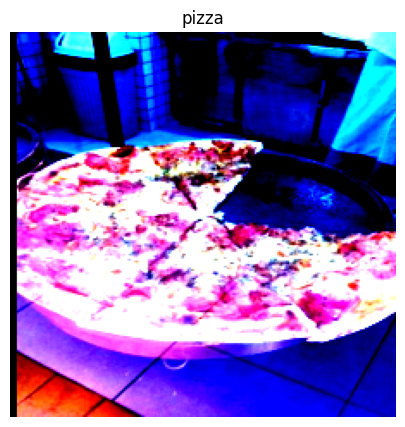

In [233]:
plt.figure(figsize = (10, 5))
plt.imshow(image[0].permute(1, 2, 0))
plt.title(train_dataset.classes[target[0]])
plt.axis("off")
plt.show()